In [1]:
# Colab 기본 환경, GPU 불필요 (PCA 기반)
!apt-get -qq install fonts-nanum > /dev/null

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.decomposition import PCA

# 한글 폰트
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print("환경 설정 완료")

환경 설정 완료


In [2]:
from google.colab import files
print("unified_features.csv 업로드해주세요")
uploaded = files.upload()

uf = pd.read_csv('unified_features.csv', index_col=0)
print(f"데이터 형태: {uf.shape}")
print(f"정상: {(uf.fault_name=='calibration').sum()}장")
print(f"이상: {(uf.fault_name!='calibration').sum()}장")

# 라벨 분리
y = uf['fault_name'].values
X_full = uf.drop(columns='fault_name')
is_fault = (y != 'calibration')
print(f"\n특징 차원: {X_full.shape[1]}")

unified_features.csv 업로드해주세요


Saving unified_features.csv to unified_features.csv
데이터 형태: (123, 8479)
정상: 103장
이상: 20장

특징 차원: 8478


In [3]:
# 컬럼명에서 블록·변수·시점 추출
def parse_col(c):
    """ 'RFM__S1V1_t00' -> ('RFM', 'S1V1', 0) """
    block, rest = c.split('__', 1)
    m = re.match(r'(.+)_t(\d+)$', rest)
    if m:
        return block, m.group(1), int(m.group(2))
    return block, rest, None

# 각 블록의 최대 시점 수 계산
block_info = {}
for c in X_full.columns:
    blk, var, t = parse_col(c)
    if t is not None:
        block_info.setdefault(blk, set()).add(t)

K = {blk: max(ts)+1 for blk, ts in block_info.items()}
print("블록별 시점 수:", K)
# 예상: {'RFM': 28, 'OES': 38, 'EV': 100}

# 각 컬럼이 어느 블록·시점인지 매핑 (한 번만 계산)
col_block = np.array([parse_col(c)[0] for c in X_full.columns])
col_time  = np.array([parse_col(c)[2] for c in X_full.columns])
print(f"컬럼 매핑 완료 ({len(col_block)}개)")

블록별 시점 수: {'RFM': 28, 'OES': 38, 'EV': 100}
컬럼 매핑 완료 (8478개)


In [4]:
# 정상 데이터만 사용
X_cal = X_full[~is_fault]
print(f"학습용 정상 데이터: {X_cal.shape}")

# 블록 정규화 (이전 융합 모델과 동일한 √(컬럼수) 가중)
weights = np.ones(X_full.shape[1])
for blk in K.keys():
    mask = (col_block == blk)
    weights[mask] = 1.0 / np.sqrt(mask.sum())

X_cal_w = X_cal.values * weights
X_all_w = X_full.values * weights

# PCA 학습 (누적분산 90%)
pca_full = PCA(n_components=0.90).fit(X_cal_w)
A = pca_full.n_components_
print(f"주성분 수: {A} (90% 분산 설명)")

# Q 통계량 (정상 기준 임계값)
def Q_stat(X_w, model):
    """SPE/Q = ||x - x_recon||²"""
    X_rec = model.inverse_transform(model.transform(X_w))
    return ((X_w - X_rec) ** 2).sum(axis=1)

Q_cal = Q_stat(X_cal_w, pca_full)
Q_threshold_full = np.quantile(Q_cal, 0.99)
print(f"99% 임계값 (전체 시점): {Q_threshold_full:.2f}")

학습용 정상 데이터: (103, 8478)
주성분 수: 68 (90% 분산 설명)
99% 임계값 (전체 시점): 0.62


In [5]:
def make_streaming_features(X_full_values, col_block, col_time, K, progress):
    """
    공정 진행률 `progress` (0~1)까지만 살리고 나머지는 0(=정상 평균)으로 마스킹.
    각 블록은 자기 시점 수의 비율만큼 진행.
    """
    X = X_full_values.copy()
    for blk, n_t in K.items():
        cutoff = int(np.ceil(progress * n_t))   # 0이면 아무것도 안 보임
        mask = (col_block == blk) & (col_time >= cutoff)
        X[:, mask] = 0  # autoscale 후 0 = 정상 평균값
    return X

# 진행률 sweep (10% ~ 100%)
progress_list = np.arange(0.1, 1.01, 0.1)
Q_streaming = np.zeros((len(progress_list), len(X_full)))

for i, p in enumerate(progress_list):
    X_p = make_streaming_features(X_full.values, col_block, col_time, K, p)
    X_p_w = X_p * weights
    Q_streaming[i] = Q_stat(X_p_w, pca_full)
    detection_rate = (Q_streaming[i, is_fault] > Q_threshold_full).mean()
    false_alarm   = (Q_streaming[i, ~is_fault] > Q_threshold_full).mean()
    print(f"진행률 {int(p*100):3d}%: 탐지율 {detection_rate*100:.0f}%, 오탐 {false_alarm*100:.1f}%")

진행률  10%: 탐지율 40%, 오탐 0.0%
진행률  20%: 탐지율 85%, 오탐 22.3%
진행률  30%: 탐지율 95%, 오탐 36.9%
진행률  40%: 탐지율 100%, 오탐 54.4%
진행률  50%: 탐지율 100%, 오탐 71.8%
진행률  60%: 탐지율 100%, 오탐 74.8%
진행률  70%: 탐지율 100%, 오탐 68.0%
진행률  80%: 탐지율 100%, 오탐 39.8%
진행률  90%: 탐지율 100%, 오탐 12.6%
진행률 100%: 탐지율 100%, 오탐 1.9%


In [6]:
# 단일 임계값(Q_threshold_full)을 모든 시점에 쓰면 초기엔 오탐 적음·후기엔 정상
# → 시점별로 정상 데이터의 99% 분위수를 각각 임계값으로
thresholds_adaptive = np.zeros(len(progress_list))
for i in range(len(progress_list)):
    thresholds_adaptive[i] = np.quantile(Q_streaming[i, ~is_fault], 0.99)

print("시점별 적응적 임계값:")
for p, th in zip(progress_list, thresholds_adaptive):
    print(f"  진행률 {int(p*100):3d}%: Q_threshold = {th:.2f}")

시점별 적응적 임계값:
  진행률  10%: Q_threshold = 0.45
  진행률  20%: Q_threshold = 0.75
  진행률  30%: Q_threshold = 0.94
  진행률  40%: Q_threshold = 1.14
  진행률  50%: Q_threshold = 1.27
  진행률  60%: Q_threshold = 1.31
  진행률  70%: Q_threshold = 1.24
  진행률  80%: Q_threshold = 0.86
  진행률  90%: Q_threshold = 0.70
  진행률 100%: Q_threshold = 0.62


In [7]:
# 각 fault 웨이퍼가 처음으로 임계값을 넘은 시점 = 탐지 시점
detection_progress = np.full(len(X_full), np.nan)
for w_idx in range(len(X_full)):
    for t_idx, p in enumerate(progress_list):
        if Q_streaming[t_idx, w_idx] > thresholds_adaptive[t_idx]:
            detection_progress[w_idx] = p
            break

# Lead Time = 100% - 탐지 시점 (얼마나 일찍 잡았나)
detection_df = pd.DataFrame({
    'wafer_id': X_full.index,
    'fault_name': y,
    'is_fault': is_fault,
    'detected_at_pct': detection_progress * 100,
    'lead_time_pct': (1 - detection_progress) * 100
})

# Fault 웨이퍼별 결과
fault_results = detection_df[detection_df['is_fault']].sort_values('detected_at_pct')
print("=== Fault 웨이퍼 탐지 결과 ===")
print(fault_results[['fault_name', 'detected_at_pct', 'lead_time_pct']].to_string(index=False))

print(f"\n평균 탐지 시점: {fault_results['detected_at_pct'].mean():.1f}%")
print(f"평균 Lead Time: {fault_results['lead_time_pct'].mean():.1f}%")
print(f"탐지된 fault: {fault_results['detected_at_pct'].notna().sum()}/{is_fault.sum()}")

=== Fault 웨이퍼 탐지 결과 ===
fault_name  detected_at_pct  lead_time_pct
  TCP +50              10.0           90.0
  RF +10               10.0           90.0
  Pr +3                10.0           90.0
  Pr -2                10.0           90.0
  Pr +2                10.0           90.0
  BCl3 -5              10.0           90.0
  RF +8                10.0           90.0
  TCP +30              10.0           90.0
  TCP -15              10.0           90.0
  TCP -20              10.0           90.0
  BCl3 +10             10.0           90.0
  RF -12               10.0           90.0
  TCP +20              10.0           90.0
  Pr +1                10.0           90.0
  Cl2 -10              20.0           80.0
  BCl3 +5              20.0           80.0
  Cl2 -5               30.0           70.0
  Cl2 +5               70.0           30.0
  TCP +10              80.0           20.0
  He Chuck             80.0           20.0

평균 탐지 시점: 22.0%
평균 Lead Time: 78.0%
탐지된 fault: 20/20


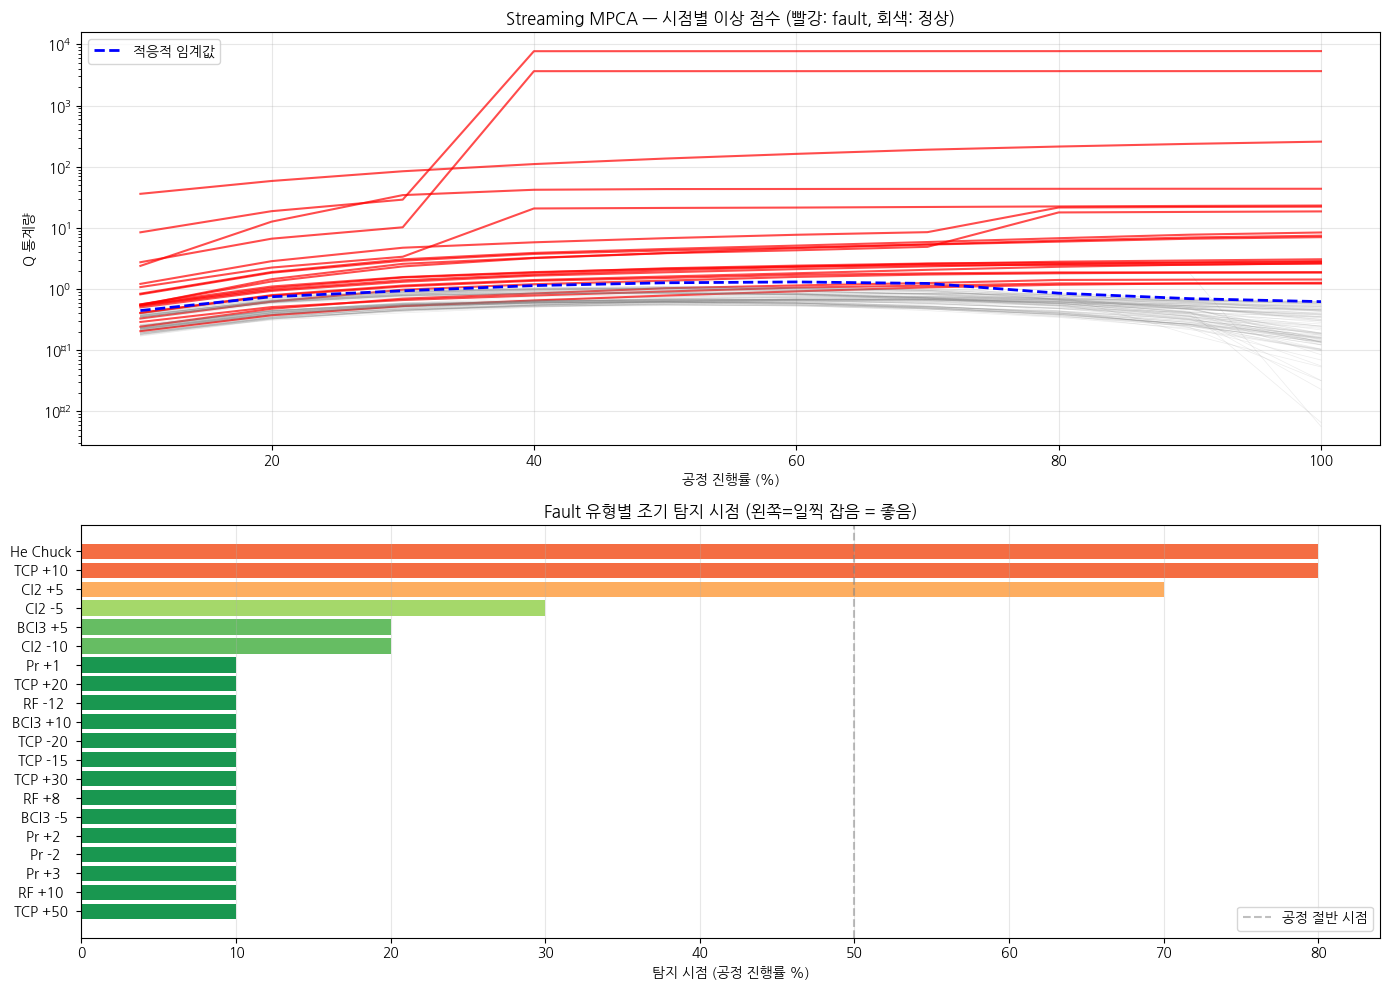

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 상단: 모든 웨이퍼의 Q 궤적
ax = axes[0]
for w_idx in range(len(X_full)):
    color = 'red' if is_fault[w_idx] else 'gray'
    alpha = 0.7 if is_fault[w_idx] else 0.15
    lw = 1.5 if is_fault[w_idx] else 0.5
    ax.plot(progress_list*100, Q_streaming[:, w_idx],
            color=color, alpha=alpha, lw=lw)

ax.plot(progress_list*100, thresholds_adaptive, 'b--', lw=2, label='적응적 임계값')
ax.set_xlabel('공정 진행률 (%)')
ax.set_ylabel('Q 통계량')
ax.set_title('Streaming MPCA — 시점별 이상 점수 (빨강: fault, 회색: 정상)')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)

# 하단: Fault 유형별 탐지 시점
ax = axes[1]
fault_only = detection_df[detection_df['is_fault']].sort_values('detected_at_pct')
colors = plt.cm.RdYlGn_r(fault_only['detected_at_pct'].values / 100)
ax.barh(fault_only['fault_name'], fault_only['detected_at_pct'], color=colors)
ax.axvline(50, color='gray', linestyle='--', alpha=0.5, label='공정 절반 시점')
ax.set_xlabel('탐지 시점 (공정 진행률 %)')
ax.set_title('Fault 유형별 조기 탐지 시점 (왼쪽=일찍 잡음 = 좋음)')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('streaming_detection.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# 결과 저장 (보고서·발표용)
detection_df.to_csv('streaming_detection_results.csv', index=False)

# 요약 metric
summary = {
    '총 웨이퍼': len(X_full),
    '정상': (~is_fault).sum(),
    '이상': is_fault.sum(),
    '탐지율 (100% 시점)': f"{(Q_streaming[-1, is_fault] > thresholds_adaptive[-1]).sum()}/{is_fault.sum()}",
    '평균 탐지 시점': f"{fault_results['detected_at_pct'].mean():.1f}%",
    '평균 Lead Time': f"{fault_results['lead_time_pct'].mean():.1f}%",
    '가장 일찍 탐지': fault_results.iloc[0]['fault_name'] + f" ({fault_results.iloc[0]['detected_at_pct']:.0f}%)",
    '가장 늦게 탐지': fault_results.iloc[-1]['fault_name'] + f" ({fault_results.iloc[-1]['detected_at_pct']:.0f}%)"
}
print("=== 예지보전 시스템 성능 요약 ===")
for k, v in summary.items():
    print(f"{k:20s}: {v}")

from google.colab import files
files.download('streaming_detection_results.csv')
files.download('streaming_detection.png')

=== 예지보전 시스템 성능 요약 ===
총 웨이퍼               : 123
정상                  : 103
이상                  : 20
탐지율 (100% 시점)       : 20/20
평균 탐지 시점            : 22.0%
평균 Lead Time        : 78.0%
가장 일찍 탐지            : TCP +50  (10%)
가장 늦게 탐지            : He Chuck (80%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>